# Notebook for reading and plotting results
Training happens in TimsEvalNotebook.ipynb

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt
import os

e:\VSCodium\OML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Random vs. Haar init layer convergence sweep 

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
init. type=random  epochs= 29 loss=0.20297  train acc=0.9581  test acc=0.9800  355s
init. type=haar  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  185s


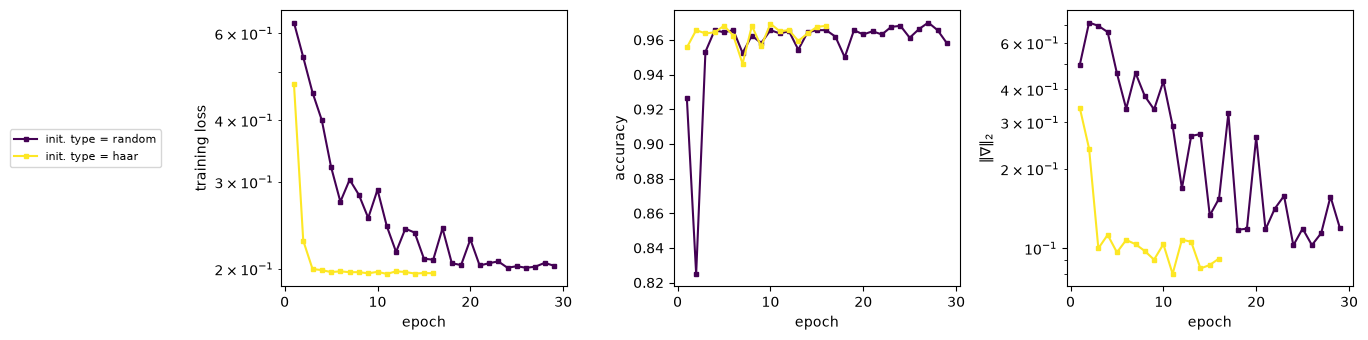

In [10]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=["random", "haar"] #all sweeps
sweep_label="init. type"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')

## Learning rate

In [46]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,0.9,1.0,1.1,1.3,1.5,1.7,2.2,2.5,2.7,3,4,5.0,10.0,50.0] #all sweeps
sweep=[0.01, 0.03, 0.1, 0.3, 0.8,1.0,1.3,1.7,2.5,3,4,5.0,10.0,50.0] #relevant sweeps

sweep_label="learning_rate"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate=0.01  epochs= 35 loss=0.36199  train acc=0.9550  test acc=0.9600  308s
learning_rate=0.03  epochs= 35 loss=0.22018  train acc=0.9600  test acc=0.9700  306s
learning_rate=0.1  epochs= 35 loss=0.19508  train acc=0.9656  test acc=0.9700  305s
learning_rate=0.3  epochs= 26 loss=0.19363  train acc=0.9650  test acc=0.9750  227s
learning_rate=0.8  epochs= 16 loss=0.19447  train acc=0.9675  test acc=0.9700  317s
learning_rate=1.0  epochs= 16 loss=0.19505  train acc=0.9681  test acc=0.9700  207s
learning_rate=1.3  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  144s
learning_rate=1.7  epochs= 16 loss=0.19744  train acc=0.9688  test acc=0.9700  142s
learning_rate=2.5  epochs= 31 loss=0.20066  train acc=0.9681  test acc=0.9775  272s
learning_rate=3  epochs= 35 loss=0.20292  train acc=0.9594  test acc=0.9700  318s
learning_rate=4  epochs= 13 loss=0.69056  train acc=0.93

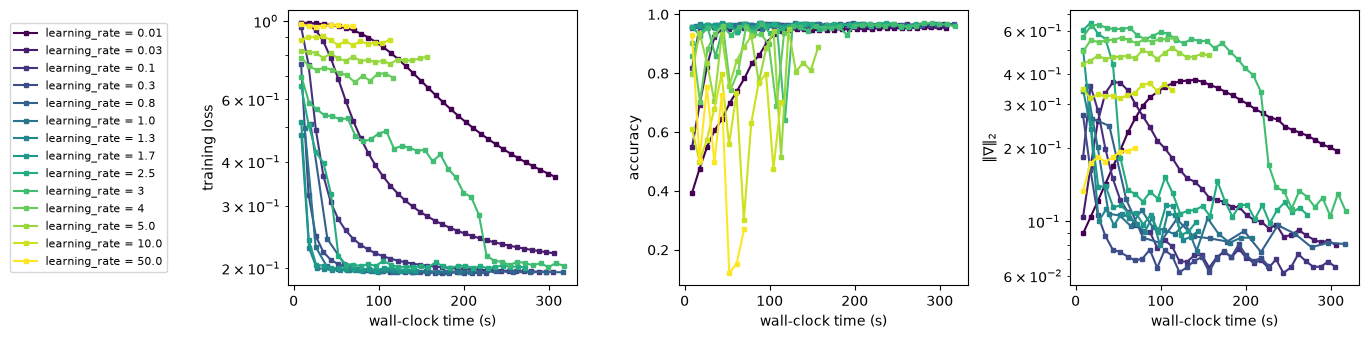

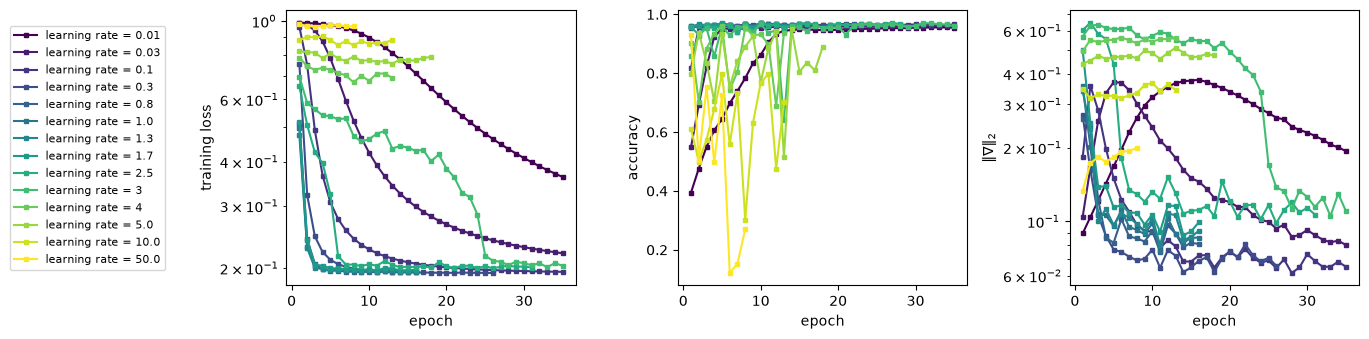

In [47]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Smaller Batchsizes

In [43]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.03,1.0,1.3,1.7,5,10] #all sweeps

sweep_label="learning_rate_smaller_batchsize"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate_smaller_batchsize=0.03  epochs= 26 loss=0.19383  train acc=0.9675  test acc=0.9775  1934s
learning_rate_smaller_batchsize=1.0  epochs= 32 loss=0.20578  train acc=0.9694  test acc=0.9750  2392s
learning_rate_smaller_batchsize=1.3  epochs= 28 loss=0.21209  train acc=0.9581  test acc=0.9675  2129s
learning_rate_smaller_batchsize=1.7  epochs= 21 loss=0.22124  train acc=0.9587  test acc=0.9525  1576s
learning_rate_smaller_batchsize=5  epochs=  7 loss=0.86037  train acc=0.9494  test acc=0.8425  521s
learning_rate_smaller_batchsize=10  epochs=  6 loss=0.90766  train acc=0.5150  test acc=0.8000  448s


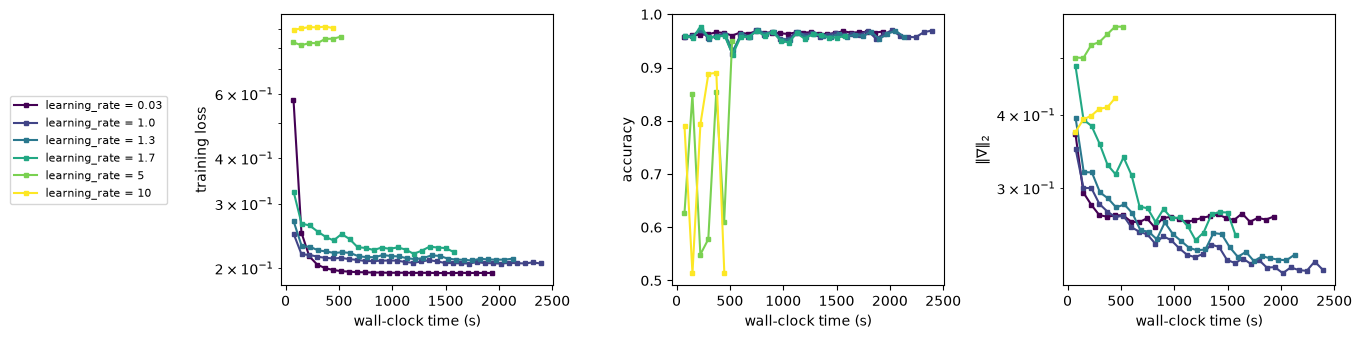

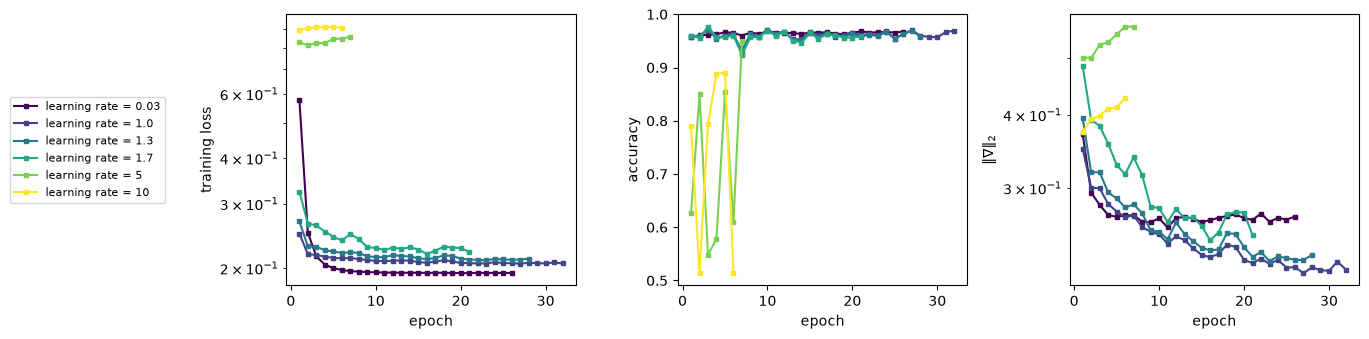

In [44]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Bigger batchsize

In [48]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[0.03,1.0,1.3,1.7,5,10] #all sweeps

sweep_label="learning_rate_bigger_batchsize"
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate_bigger_batchsize=0.03  epochs= 35 loss=0.41603  train acc=0.9544  test acc=0.9600  154s
learning_rate_bigger_batchsize=1.0  epochs= 27 loss=0.19491  train acc=0.9700  test acc=0.9700  130s
learning_rate_bigger_batchsize=1.3  epochs= 27 loss=0.19559  train acc=0.9706  test acc=0.9675  126s
learning_rate_bigger_batchsize=1.7  epochs= 14 loss=0.19488  train acc=0.9619  test acc=0.9575  71s
learning_rate_bigger_batchsize=5  epochs= 13 loss=0.82526  train acc=0.9525  test acc=0.9000  63s
learning_rate_bigger_batchsize=10  epochs= 16 loss=0.90223  train acc=0.5044  test acc=0.5775  79s


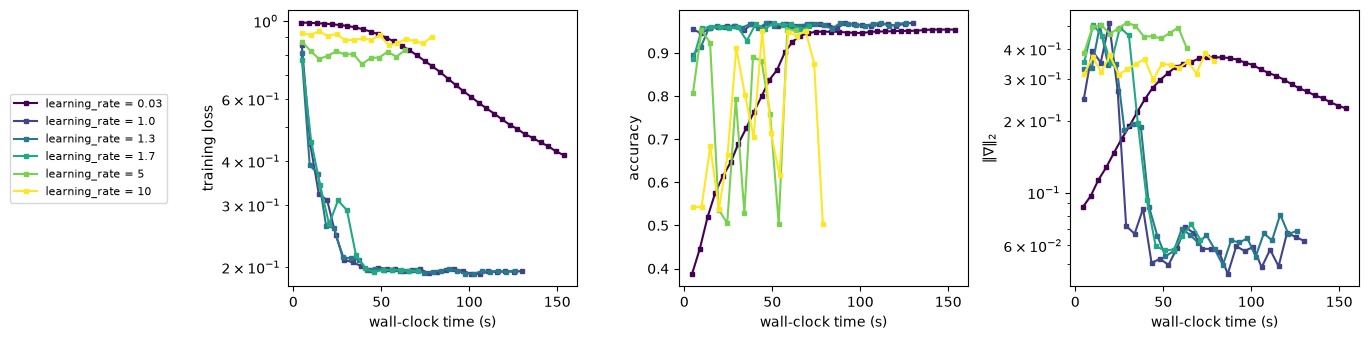

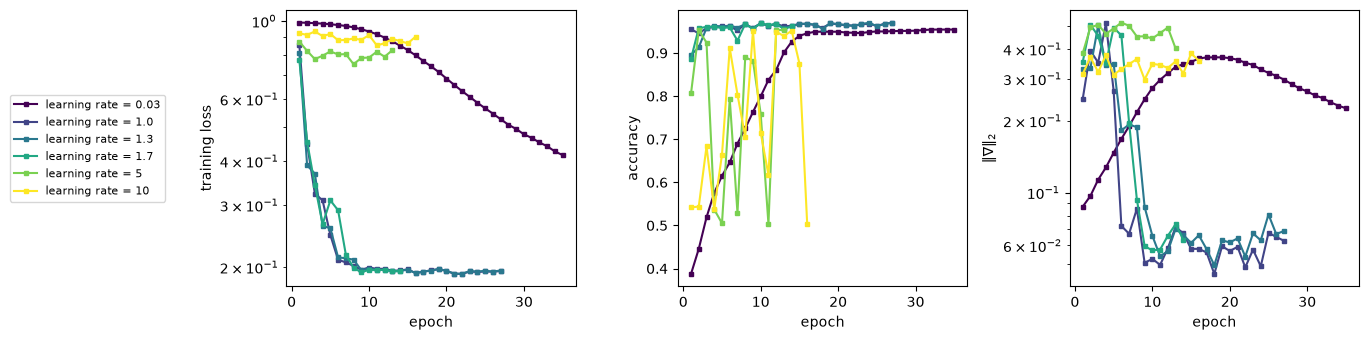

In [49]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning_rate" ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label="learning rate" ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Sidelength m

In [3]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep = [6,8,10,14,18,22]
sweep_label = "m_sidelength"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    #test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)
    

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
m_sidelength=6  epochs=  5 loss=0.22518  train acc=0.9225  test acc=0.9400  5s
m_sidelength=8  epochs=  5 loss=0.18545  train acc=0.9600  test acc=0.9625  15s
m_sidelength=10  epochs=  5 loss=0.19703  train acc=0.9681  test acc=0.9775  38s
m_sidelength=14  epochs=  5 loss=0.22042  train acc=0.9700  test acc=0.9800  161s
m_sidelength=18  epochs=  5 loss=0.25275  train acc=0.9663  test acc=0.9750  596s
m_sidelength=22  epochs=  5 loss=0.24848  train acc=0.9644  test acc=0.9750  1416s


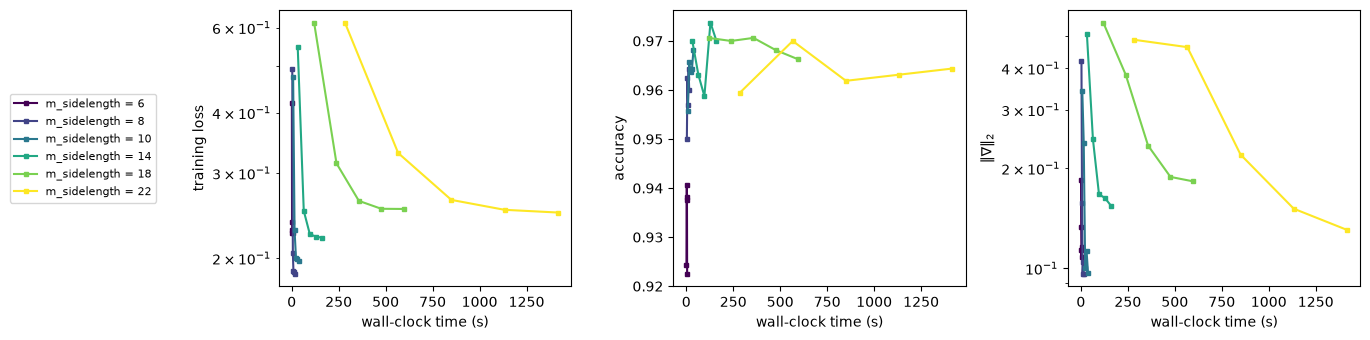

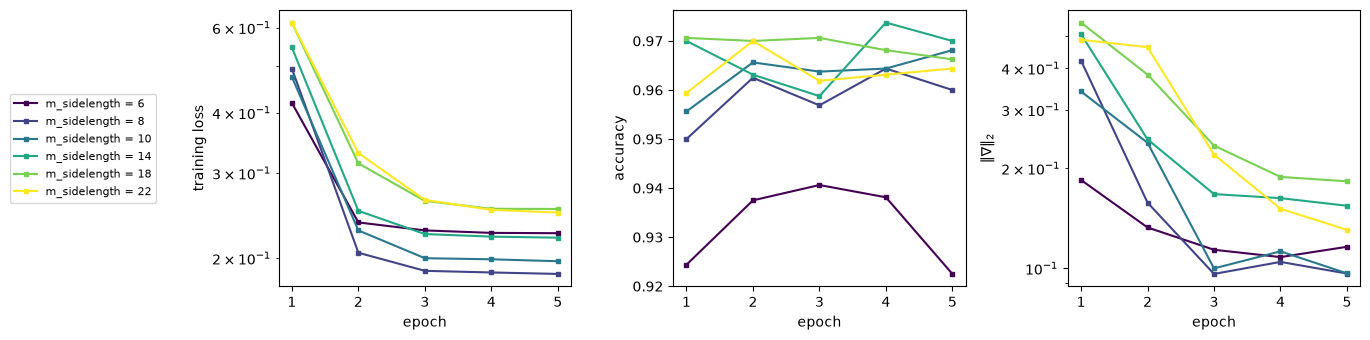

In [5]:
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="time")
plt.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')
# Just plotting relevant sweeps
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')


## Layer number

Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
Layer count=10  epochs= 10 loss=0.81487  train acc=0.5856  test acc=0.5875  12s
Layer count=50  epochs=  6 loss=0.41135  train acc=0.9206  test acc=0.9350  35s
Layer count=100  epochs=  8 loss=0.19747  train acc=0.9637  test acc=0.9625  95s
Layer count=150  epochs=  8 loss=0.20130  train acc=0.9594  test acc=0.9500  140s
Layer count=200  epochs=  7 loss=0.20836  train acc=0.9688  test acc=0.9750  182s


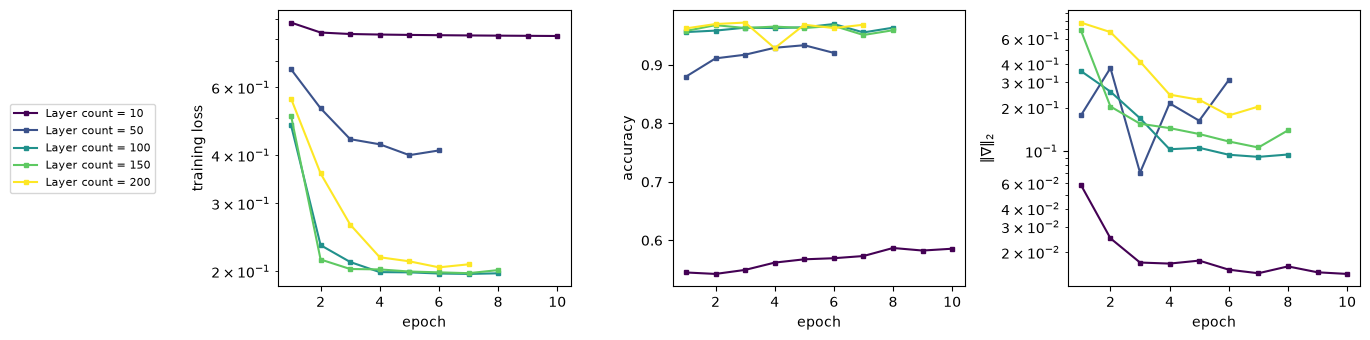

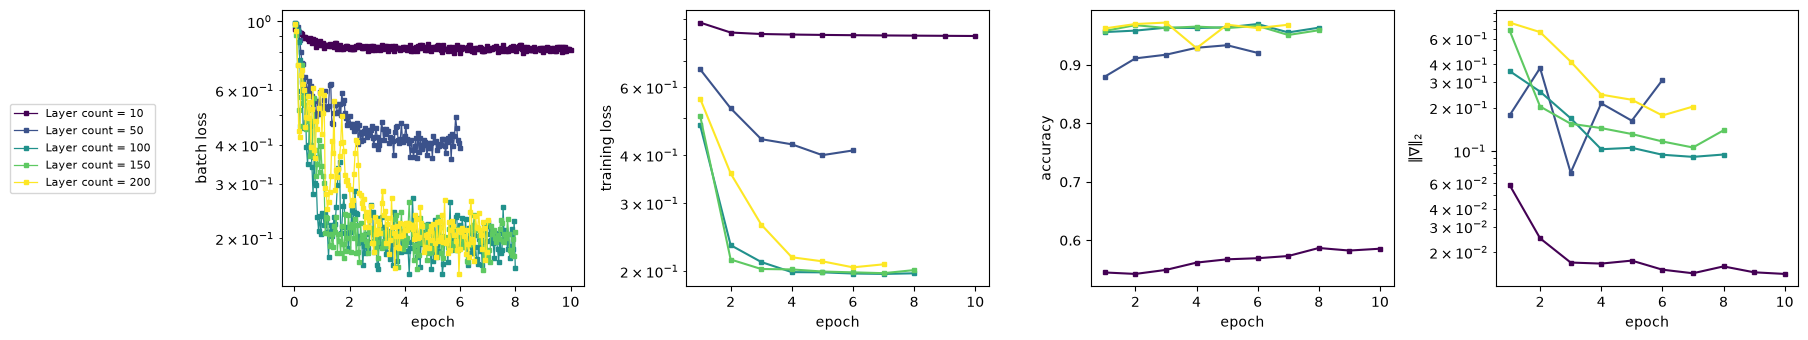

In [6]:
values = np.array([1,7])#figures you want from the mnist dataset
number = 2000            #Sets number of samples you want to get in total
m_side = 10             #side length (pixel) of mnist image after downsampling
theta_enc = 1           #mysterious hyper parameter for amplitude scaling
norm_energy = True      #Bool for if energy of encoded image should be normalized or not
seed = 1550             #Random seed to control random choice of number -pictures out of the available ones, 
                        #seed = None leads to random results for each iteration
balanced = True         #Enforcing equality of classes
split_ratio = 0.8       #Sets training-sample proportion

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep=[10,50,100,150,200] #all sweeps
sweep_label="Layer count"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s}.json"))
    test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("loss", "acc", "grad_norm"), x_axis="epoch")
plt.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')
fig, _ = plot_training(trainers, sweep_values=sweep, sweep_label=sweep_label ,keys=("batch_loss", "loss", "acc", "grad_norm"), x_axis="epoch")

## Batch size

In [18]:
def training_sweep_batch_size(sweep_param, values, number, m, theta_enc, normalize_energy,
                      param_init_seed, balanced, split_ratio, encoding,
                      detectors, loss_kind, learning_rate, batch_size,
                      init, max_epochs, patience, min_delta,
                      eta_bs, alpha_fiber, verbose):
    
    sweep = sweep_param[0]
    sweep_label = sweep_param[1]

    # Perform training
    trainers = []
    for s in sweep:
        cfg = TrainConfig(m, theta_enc, normalize_energy, encoding,
                          detectors, loss_kind, learning_rate, s, #s for batch_size
                          init, max_epochs, patience, min_delta,
                          param_init_seed, eta_bs, alpha_fiber)
        E_tr, y_tr, E_te, y_te = get_data(values, number, m,
                                          theta_enc, normalize_energy,
                                          param_init_seed, verbose)
        t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
        t.fit(E_tr, y_tr)
        t.test_acc = t.evaluate(E_te, y_te)[1]
        t.save(f"results/{sweep_label}/{s}.json", test_acc=t.test_acc)
        trainers.append(t)

    # Plot trainingresults
    for s, t in zip(sweep, trainers):
        print(f"m={m:3d}  N={m*m:4d}  epochs={len(t.history['loss']):3d}  "
              f"loss={t.history['loss'][-1]:.5f}  "
              f"train acc={t.history['acc'][-1]:.4f}  "
              f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

    fig, _ = plot_training(trainers, sweep, keys=(
    "batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label, x_axis="epoch")

    fig.savefig(f"results/{sweep_label}/plot_training_epoch.png",
                dpi=600, bbox_inches='tight')

    fig, _ = plot_training(trainers, sweep, keys=(
    "batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label, x_axis="time")
    fig.savefig(f"results/{sweep_label}/plot_training_time.png",
                dpi=600, bbox_inches='tight')

Train:   160 samples, class counts {1: 80, 7: 80}
Test :    40 samples, class counts {1: 20, 7: 20}
batch_size=1  epochs= 10 loss=0.18976  train acc=0.9625  test acc=0.9750  443s
batch_size=2  epochs= 10 loss=0.19090  train acc=0.9625  test acc=0.9750  192s
batch_size=4  epochs= 10 loss=0.20089  train acc=0.9563  test acc=1.0000  98s
batch_size=8  epochs= 10 loss=0.23690  train acc=0.9500  test acc=1.0000  49s
batch_size=16  epochs= 10 loss=0.33747  train acc=0.9500  test acc=0.9750  26s
batch_size=32  epochs= 10 loss=0.63143  train acc=0.9500  test acc=1.0000  14s
batch_size=64  epochs= 10 loss=0.86686  train acc=0.9062  test acc=0.9750  10s
batch_size=128  epochs= 10 loss=0.94548  train acc=0.8000  test acc=0.8250  8s
batch_size=256  epochs= 10 loss=0.98084  train acc=0.5750  test acc=0.6000  5s
batch_size=512  epochs= 10 loss=0.98084  train acc=0.5750  test acc=0.6000  5s


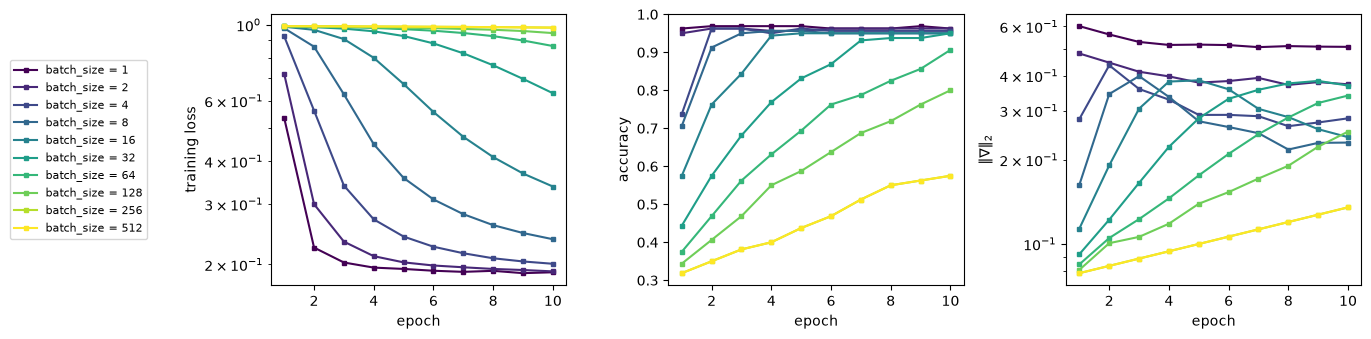

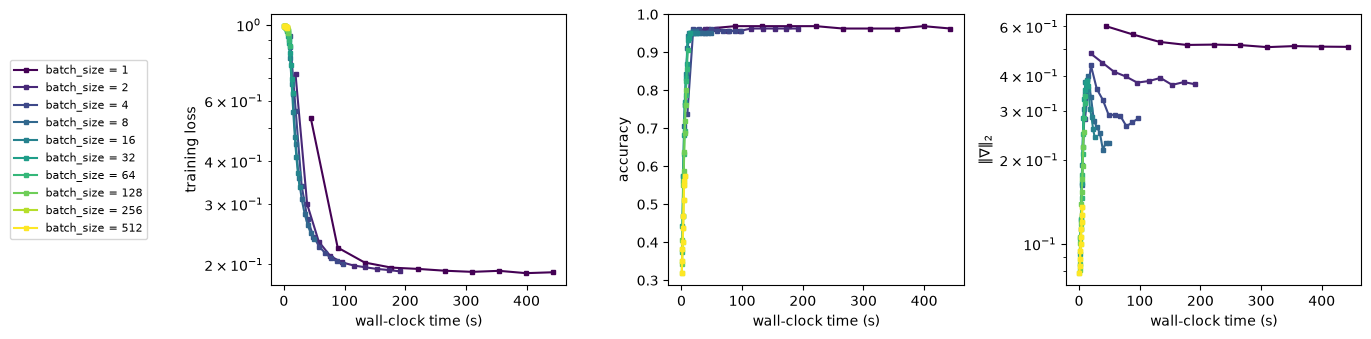

In [27]:
values = np.array([1, 7])  # digits you want from the mnist dataset
number = 200  # Sets number of samples you want to get in total
m = 10  # side length (pixel) of mnist image after downsampling
norm_energy = True  # Bool for if energy of encoded image should be normalized or not
seed = 1550  # Random seed to control random choice of number -pictures out of the available ones,
# seed = None leads to random results for each iteration
balanced = True  # Enforcing equality of classes
split_ratio = 0.8  # Sets training-sample proportion
verbose = False

# Standard parameters specific to OML system
theta_enc = 1
encoding = 'amplitude'
detectors = (33, 66)
loss_kind = 'mse'
learning_rate = 0.1
batch_size = 1
init = "haar"
max_epochs = 10
patience = 20
min_delta = 1e-4
eta_bs = 1.0
alpha_fiber = 0.0

E_train, Y_train, E_test, Y_test = get_data(values, number, m_side, 
                        theta_enc, norm_energy, seed, balanced, split_ratio) 

trainers = []
sweep = [1,2,4,8,16,32,64,128,256,512]
sweep_label = "batch_size"

for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s}.json"))
    #test_loss, test_acc = t.evaluate(E_test, Y_test)
    trainers.append(t)
    

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

fig, _ = plot_training(trainers, sweep, keys=(
    "loss", "acc", "grad_norm"), sweep_label=sweep_label, x_axis="epoch")

fig.savefig(f"results/{sweep_label}/plot_training_epoch.png",
            dpi=600, bbox_inches='tight')

fig, _ = plot_training(trainers, sweep, keys=(
 "loss", "acc", "grad_norm"), sweep_label=sweep_label, x_axis="time")
fig.savefig(f"results/{sweep_label}/plot_training_time.png",
            dpi=600, bbox_inches='tight')